# Fixed Effects Validation

**Author:** Alejandro Orellana

**Date:** Janurary 22, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal

**Purpose:** Process of trying to validate the findings of fixed_effects.ipynb by adding more variables

## Section 1: Loading Data

In [1]:
from utils.data_utils import load_data
from utils.fix_effect_utils import (
    prepare_analysis,
    prepared_dataframe,
    run_sensitivity_models,
)
from utils.plot_utils import plot_fixed_effects_coefficients, plotting_FE_star_coef

panel_data = prepared_dataframe(load_data())
target_col = "Weather Normalized Site EUI (kBtu/sq ft)"
rating_col = "Chicago Energy Rating"
analysis_df = prepare_analysis(panel_data, target_col, rating_col)
analysis_df.head(3)

2026-02-28 21:28:35,532 [INFO] generated new fontManager
2026-02-28 21:28:39,776 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-02-28 21:28:39,780 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


----------------------------------------
DATA ANALYSIS PREP SUMMARY
----------------------------------------
Initial Total Rows:        10240
Initial Unique Buildings:  1280
----------------------------------------
Rows with Future Change:   7681
Unique Buildings Retained: 1280
Unique Buildings Lost: 0
----------------------------------------


,Data Year,ID,Property Name,Address,ZIP Code,Community Area,Primary Property Type,Gross Floor Area - Buildings (sq ft),Year Built,# of Buildings,...,COVID Impact Category,Effective Year Built,Time Built,Current_EUI,Next_Year_EUI,Future_Change_Raw,Future_Change,Rating_Numeric,Rating_Cat,Post_Policy
11603,2016,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,194.6,186.9,-7.7,-7.7,NaN,None,0
2543,2017,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,186.9,186.5,-0.4,-0.4,NaN,None,0
28282,2018,100001,presence smemc st elizabeth campus,1431 North Claremont Ave,60622,west town,hospital,309056.0,1928.0,1.0,...,Other,1928.0,1920-1960,186.5,NaN,NaN,NaN,NaN,None,0


# Fixed Effect Validation

The function below goes the base version (with only Star Score) and addtional variables. To see whether the outcomes come out consistent in trends and also whether the star score is as signifcant as the fixed_effect.ipynb has found

In [2]:
sensitivity_list = run_sensitivity_models(analysis_df)

Status               | Model Name
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:          Future_Change   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     29.96
Date:                Sat, 28 Feb 2026   Prob (F-statistic):           7.58e-41
Time:                        21:28:40   Log-Likelihood:                -20263.
No. Observations:                5037   AIC:                         4.054e+04
Df Residuals:                    5030   BIC:                         4.059e+04
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------

/project/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 12
  warnings.warn('covariance of constraints does not have full '
/project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 19, but rank is 16
  warnings.warn('covariance of constraints does not have full '


1. Base Star Rating


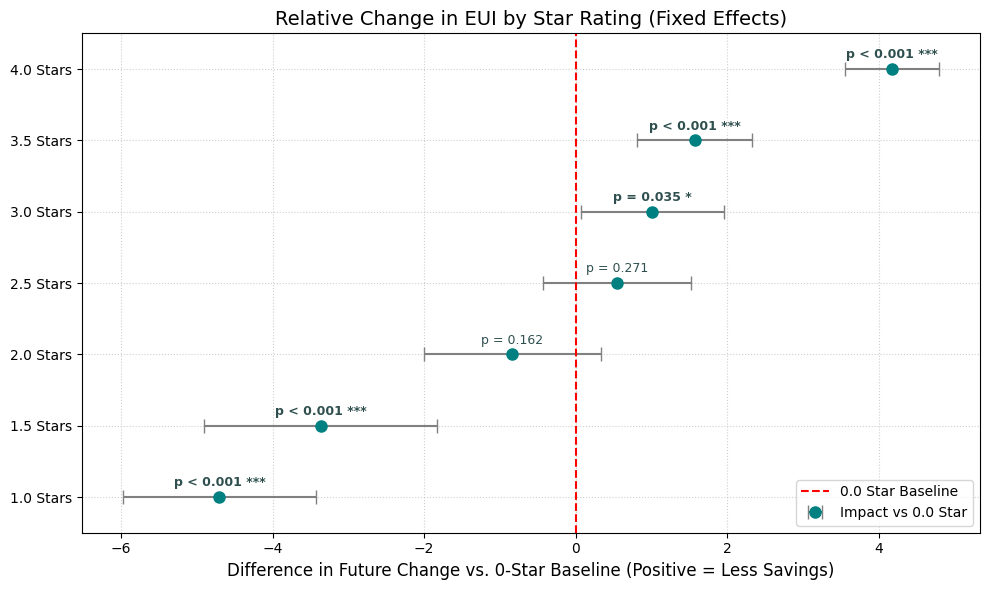

In [3]:
print(list(sensitivity_list.items())[0][0])
fig, ax = plot_fixed_effects_coefficients(list(sensitivity_list.items())[0][1])

"1. Base Star Rating": "Future_Change ~ C(Rating_Cat, Treatment(reference='0.0'))"
- This model shows a highly significant correlation where 1-Star buildings appear to improve by ~3 EUI units more than the baseline, showing the optimistic results of the fixed_effects.ipynb. However, this naive model assumes that only the stars drive the change, failing to account for why those buildings were inefficient in the first place.


2. +Control (EUI)


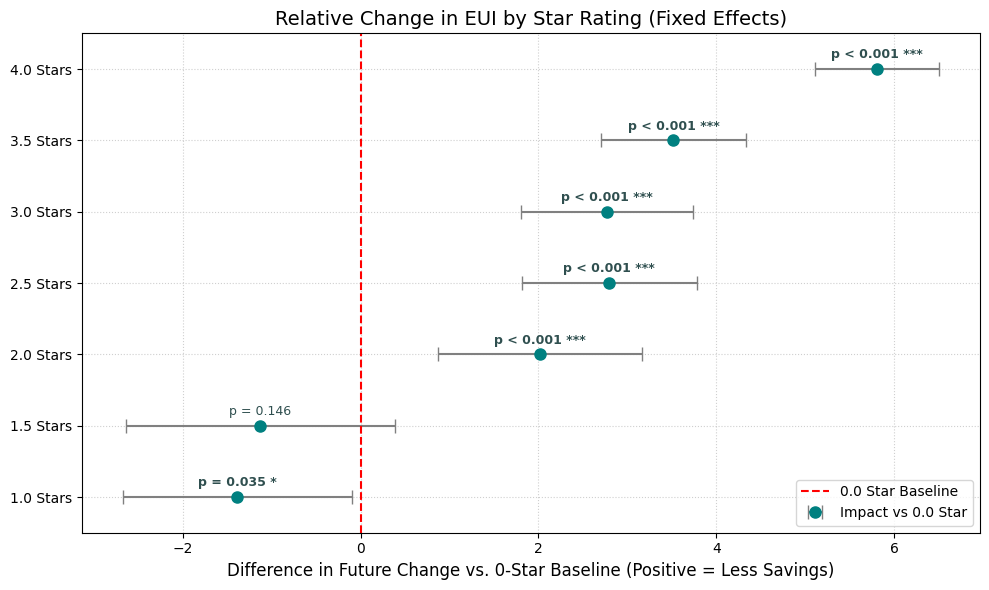

In [4]:
print(list(sensitivity_list.items())[1][0])
fig, ax = plot_fixed_effects_coefficients(list(sensitivity_list.items())[1][1])

"2. +Control (EUI)": "Future_Change ~ C(Rating_Cat, Treatment(reference='0.0')) + Q('Current_EUI')"
- Adding the baseline EUI decrease the 1-Star coefficient by over 50% (from -2.96 to -1.39), proving that the majority of the previously observed improvement could be mean reversion (inefficient buildings naturally improving). While the effect remains barely significant (p=0.035), this result shows that the fixed_effects.ipynb is biased rather than the placard having an effect.

3. +Control (EUI + Year)


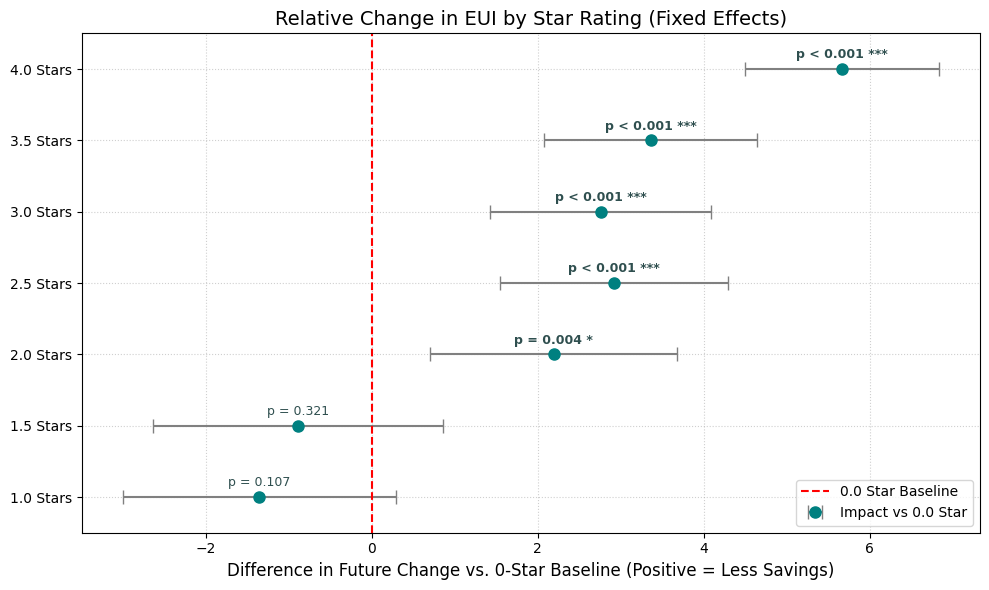

In [5]:
print(list(sensitivity_list.items())[2][0])
fig, ax = plot_fixed_effects_coefficients(list(sensitivity_list.items())[2][1])

"3. +Control (EUI + Year)": "Future_Change ~ C(Rating_Cat, Treatment(reference='0.0')) + Q('Current_EUI') + C(Q('Data Year'))"
- Controlling for Data Year has 1-Star coefficient statistically insignificant (p=0.107), meaning the "Placard Effect" is not reliable for prediction. The model attributes the improvement during 2019/2020 Covid Shutdown rather than the ratings themselves.

4. +Control (EUI + Year + Age)


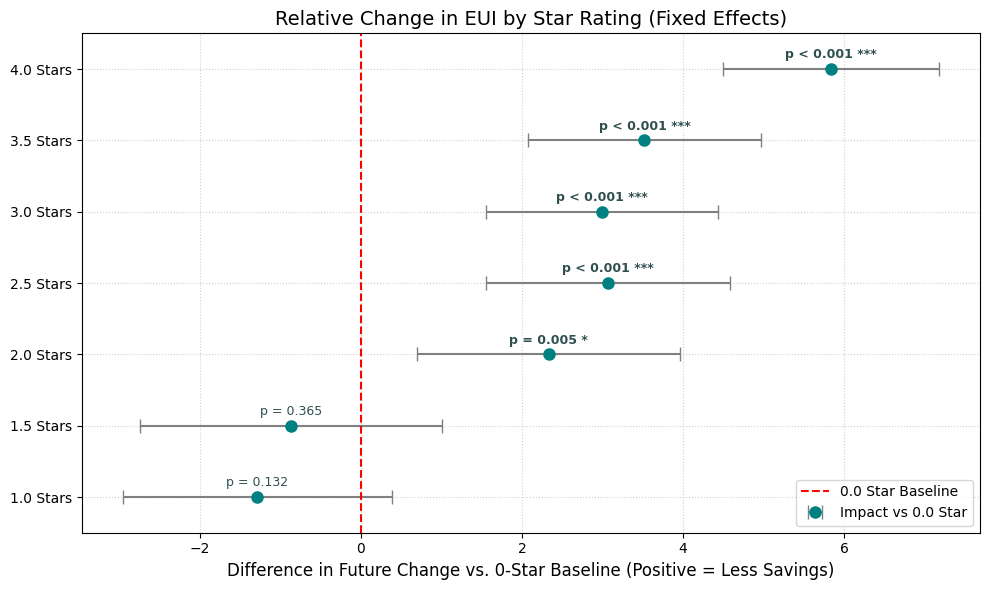

In [6]:
print(list(sensitivity_list.items())[3][0])
fig, ax = plot_fixed_effects_coefficients(list(sensitivity_list.items())[3][1])

"4. +Control (EUI + Year + Age)": "Future_Change ~ C(Rating_Cat, Treatment(reference='0.0')) + Q('Current_EUI') + C(Q('Data Year')) + C(Q('Time Built'))"
- Adding building age categories provides no additional explanatory power and leaves the 1-Star coefficient insignificant (p=0.132). This confirms that the failure of the model is not due to missing characteristics of the buildings. Meaning that the current approach of Linear Regression to separate the policy from the  pandemic may be wrong.

This analysis validation shows that the supposed success of the Energy Rating policy in the linear model was a False Positive. Possible driven by EUI (specifically Weather Normalized Site EUI (kBtu/sq ft)) mean reversion and pandemic dropping energy usage. Since the "Star Effect" is gone when controlling for these factors, the fixed_effects.pynb methodology is not sufficent for causal inference and may be representative of something else

These visualizations above shows although stars above 1.5 are show some improvement but does not show significant differences in the rate between the stars. Meaning the effects between the stars may be inconsequenial on energy usage trends.

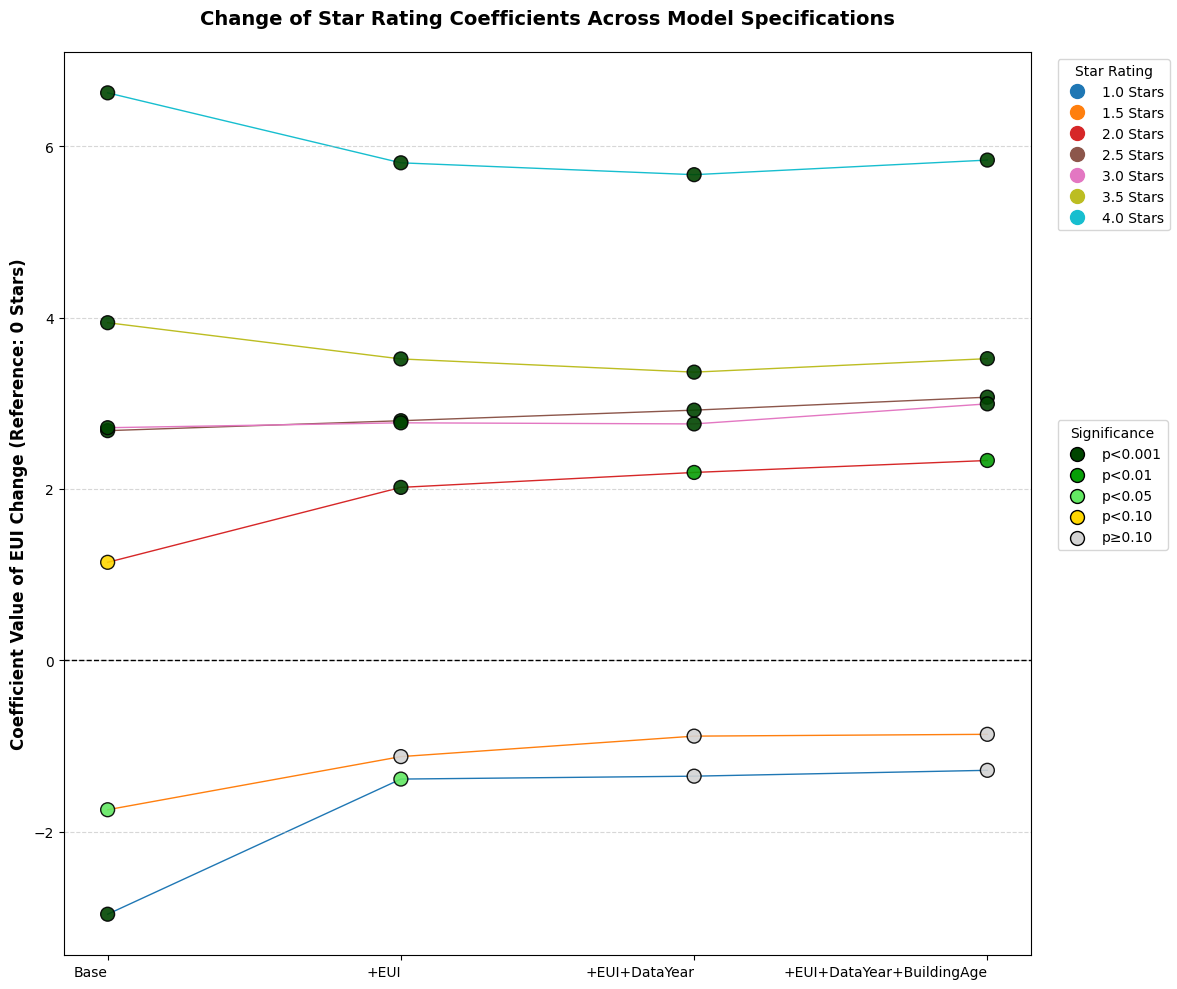

In [7]:
base = (list(sensitivity_list.items())[0][1], "Base")
with_eui = (list(sensitivity_list.items())[1][1], "+EUI")
with_eui_year = (list(sensitivity_list.items())[2][1], "+EUI+DataYear")
with_eui_year_age = (list(sensitivity_list.items())[3][1], "+EUI+DataYear+BuildingAge")

all_formulas = [base, with_eui, with_eui_year, with_eui_year_age]
plot = plotting_FE_star_coef(all_formulas)

Base formula:
- Dependent Variable: EUI Change
- Independent Variable: Star Score

The dependent variable is Weather Normalized Site EUI. The graph illustrates that as more building characteristics are added to the fixed effect model, the coefficients for the star ratings begin to converge. For the 1.0 and 1.5 Star ratings (the bottom two lines), the effects become statistically insignificant (indicated by grey lines, p > 0.1). Meanwhile, ratings 2.0 through 3.5 converge to a narrower positive range, while the 4-Star rating stands alone. An interpretation is that the Star Score is less of an influence on EUI and more of a reflection of three distinct building types: low-performing, mid-range, and high-performing.

Example of EUI Change: The base model shows a ~6 unit difference between the coefficients for 1.5 Stars (rounded to -2.0) and 3.5 Stars (rounded to +4.0). This implies that if two identical buildings were subjected to the same conditions, the 3.5-Star building would reduce its EUI by 6 fewer units than the 1.5-Star building. However, because the coefficient for the 1.5-Star group is statistically insignificant, there is no confidence that this is a true difference and effect.